# IE6600 – Quiz 6
## CTR Dataset Analysis and Visualization
Name: Pranit Choudhary

Course: Computation and Visualization for Analytics


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("ad_10000records.csv")

# Display basic information
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())


Shape: (10000, 10)

Columns:
['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Ad Topic Line', 'City', 'Gender', 'Country', 'Timestamp', 'Clicked on Ad']

First 5 rows:


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Gender,Country,Timestamp,Clicked on Ad
0,62.26,32.0,69481.85,172.83,Decentralized real-time circuit,Lisafort,Male,Svalbard & Jan Mayen Islands,2016-06-09 21:43:05,0
1,41.73,31.0,61840.26,207.17,Optional full-range projection,West Angelabury,Male,Singapore,2016-01-16 17:56:05,0
2,44.40,30.0,57877.15,172.83,Total 5thgeneration standardization,Reyesfurt,Female,Guadeloupe,2016-06-29 10:50:45,0
3,59.88,28.0,56180.93,207.17,Balanced empowering success,New Michael,Female,Zambia,2016-06-21 14:32:32,0
4,49.21,30.0,54324.73,201.58,Total 5thgeneration standardization,West Richard,Female,Qatar,2016-07-21 10:54:35,1


## 1) Data Loading and Initial Exploration

In [35]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Check null values
print("\nNull values by column:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary statistics:")
display(df.describe())


Duplicate rows: 215

Null values by column:
Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Gender                      0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64

Summary statistics:


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Clicked on Ad
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,61.660757,35.940100,53840.047721,177.759831,0.491700
std,15.704142,8.572973,13343.708718,40.820951,0.499956
min,32.600000,19.000000,13996.500000,105.220000,0.000000
25%,48.860000,29.000000,44052.302500,140.150000,0.000000
50%,59.590000,35.000000,56180.930000,178.920000,0.000000
75%,76.580000,42.000000,61840.260000,212.670000,1.000000
max,90.970000,60.000000,79332.330000,269.960000,1.000000


### 
The dataset is loaded using pandas.read_csv(), which reads the CSV file into a DataFrame. Initial exploration involves checking the dataset structure, identifying duplicate rows, and detecting missing values. Duplicate rows are identified using df.duplicated().sum(), while missing values in each column are detected using df.isnull().sum(). This step is important to ensure data quality before performing analysis or visualization.

## 2) Handling Missing and Impossible Values

We check for missing values in `Age` and `Area Income`, convert impossible values to null, and then impute using the median.


In [36]:
print("Before cleaning:")
print(df[['Age', 'Area Income']].isnull().sum())

# Convert impossible values to NaN
df.loc[df['Age'] <= 0, 'Age'] = np.nan
df.loc[df['Area Income'] <= 0, 'Area Income'] = np.nan

# Median imputation
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Area Income'] = df['Area Income'].fillna(df['Area Income'].median())

print("\nAfter cleaning:")
print(df[['Age', 'Area Income']].isnull().sum())


Before cleaning:
Age            0
Area Income    0
dtype: int64

After cleaning:
Age            0
Area Income    0
dtype: int64


### 
Missing values and impossible values must be handled to ensure reliable analysis. First, unrealistic values such as negative ages or zero income can be converted to NaN. After that, missing values can be filled using statistical imputation methods such as the median. The median is often preferred because it is robust to outliers and skewed distributions. This ensures that the dataset remains consistent without introducing large bias.

## 3) Box Plot: Daily Time Spent on Site vs Clicked on Ad

<Figure size 800x500 with 0 Axes>

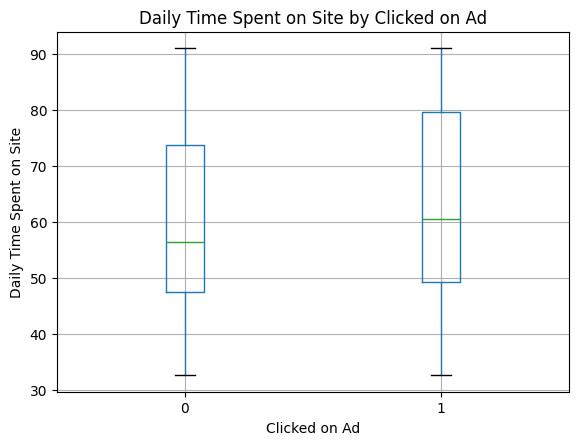

In [37]:
plt.figure(figsize=(8,5))
df.boxplot(column='Daily Time Spent on Site', by='Clicked on Ad')
plt.title('Daily Time Spent on Site by Clicked on Ad')
plt.suptitle('')
plt.xlabel('Clicked on Ad')
plt.ylabel('Daily Time Spent on Site')
plt.show()


## 4) Customized Box Plot for Age with Mean

C:\Users\prani\AppData\Local\Temp\ipykernel_29168\2090092731.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df['Age'], showmeans=True, labels=['Age'])


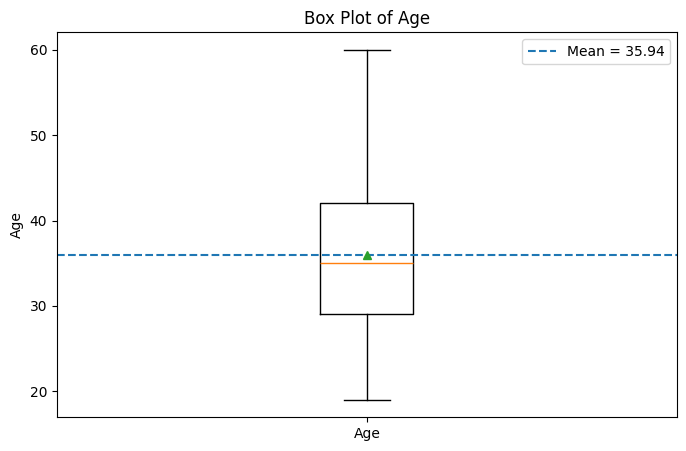

In [38]:
age_mean = df['Age'].mean()

plt.figure(figsize=(8,5))
plt.boxplot(df['Age'], showmeans=True, labels=['Age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')
plt.axhline(age_mean, linestyle='--', label=f'Mean = {age_mean:.2f}')
plt.legend()
plt.show()


### 
showmeans=True displays the mean.

labels=['Age'] labels the x-axis category.

axhline() adds a horizontal reference line for the mean.

## 5) Customized Box Plot for Area Income (Whiskers and Outliers)

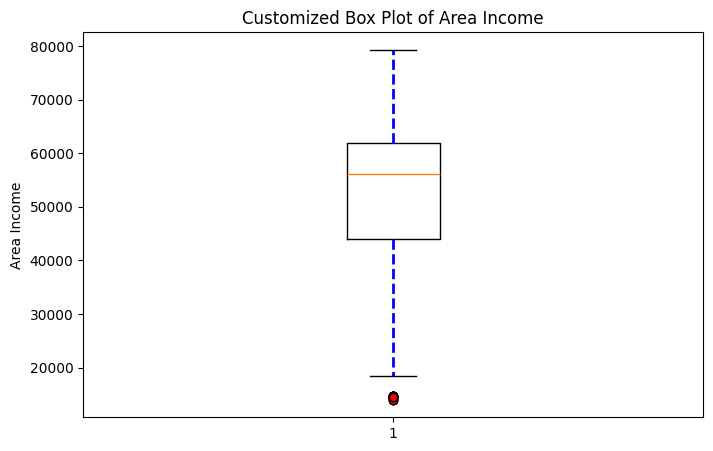

In [39]:
plt.figure(figsize=(8,5))
plt.boxplot(
    df['Area Income'],
    whiskerprops=dict(color='blue', linestyle='--', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='red', markeredgecolor='black', markersize=6)
)
plt.title('Customized Box Plot of Area Income')
plt.ylabel('Area Income')
plt.show()


###
In a box plot, whiskers represent the range of the data excluding extreme values, while outliers are observations that fall far outside the typical range of the dataset. In this visualization, the whiskers are customized using the whiskerprops parameter to change their color, line style, and thickness. This makes the boundaries of the data distribution easier to distinguish.

Outliers are customized using the flierprops parameter, which allows modification of their marker shape, size, and color. Highlighting outliers visually helps identify unusual observations in the dataset, such as extremely high or low income values.

Customizing these elements improves the readability of the plot and makes it easier to interpret the spread of the data and detect anomalies.


## 6) Side-by-Side Box Plots for Daily Internet Usage by Age Group

C:\Users\prani\AppData\Local\Temp\ipykernel_29168\3467925627.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped_data, labels=labels)


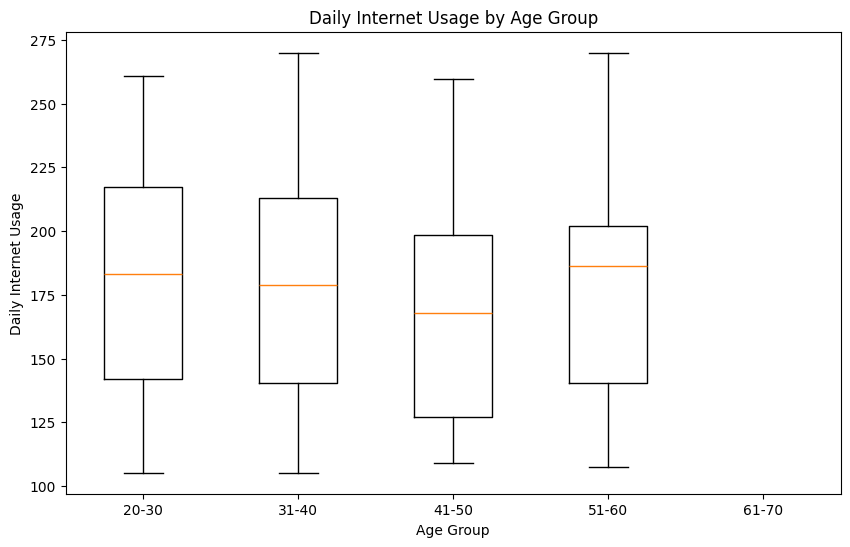

In [40]:
bins = [20, 30, 40, 50, 60, 70]
labels = ['20-30', '31-40', '41-50', '51-60', '61-70']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True, include_lowest=True)

grouped_data = [df[df['Age Group'] == group]['Daily Internet Usage'] for group in labels]

plt.figure(figsize=(10,6))
plt.boxplot(grouped_data, labels=labels)
plt.title('Daily Internet Usage by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Daily Internet Usage')
plt.show()


## 7) Handling and Visualizing Outliers in Daily Time Spent on Site

Number of outliers: 0


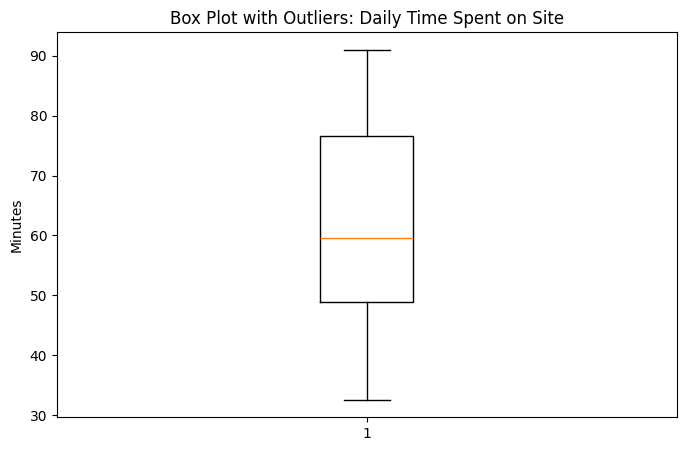

In [41]:
Q1 = df['Daily Time Spent on Site'].quantile(0.25)
Q3 = df['Daily Time Spent on Site'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Daily Time Spent on Site'] < lower) | (df['Daily Time Spent on Site'] > upper)]
print("Number of outliers:", len(outliers))

plt.figure(figsize=(8,5))
plt.boxplot(df['Daily Time Spent on Site'])
plt.title('Box Plot with Outliers: Daily Time Spent on Site')
plt.ylabel('Minutes')
plt.show()


###
Outliers can be detected using the Interquartile Range (IQR) method. First, the first quartile (Q1) and third quartile (Q3) are calculated, and the IQR is defined as Q3 − Q1. Observations that fall below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are considered outliers. Box plots are commonly used to visualize outliers because they show the spread of the data along with extreme values. Outliers can either be removed, capped, or kept depending on the purpose of the analysis.

## 8) Multi-Level Grouped Boxplots: Daily Internet Usage by Gender and Clicked on Ad

C:\Users\prani\AppData\Local\Temp\ipykernel_29168\3628136789.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


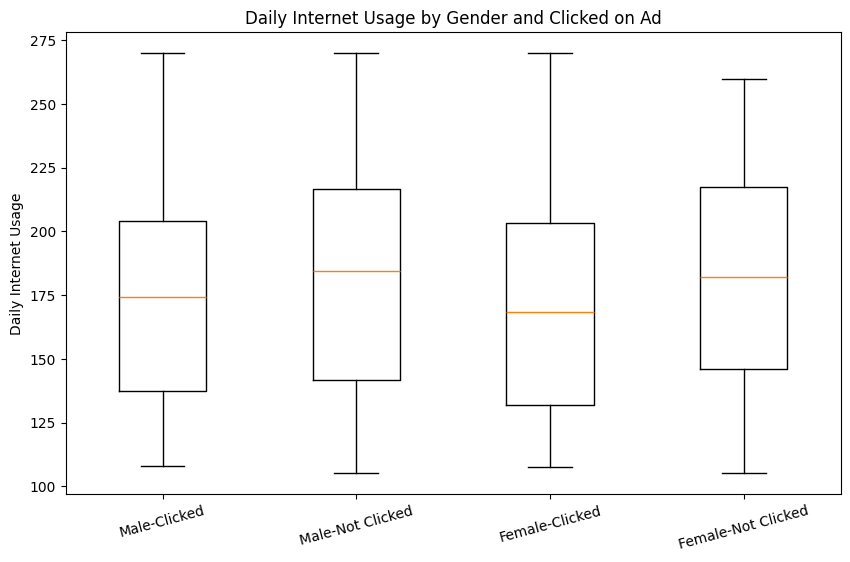

In [42]:
male_clicked = df[(df['Gender'] == 'Male') & (df['Clicked on Ad'] == 1)]['Daily Internet Usage']
male_not_clicked = df[(df['Gender'] == 'Male') & (df['Clicked on Ad'] == 0)]['Daily Internet Usage']
female_clicked = df[(df['Gender'] == 'Female') & (df['Clicked on Ad'] == 1)]['Daily Internet Usage']
female_not_clicked = df[(df['Gender'] == 'Female') & (df['Clicked on Ad'] == 0)]['Daily Internet Usage']

plt.figure(figsize=(10,6))
plt.boxplot(
    [male_clicked, male_not_clicked, female_clicked, female_not_clicked],
    labels=['Male-Clicked', 'Male-Not Clicked', 'Female-Clicked', 'Female-Not Clicked']
)
plt.title('Daily Internet Usage by Gender and Clicked on Ad')
plt.ylabel('Daily Internet Usage')
plt.xticks(rotation=15)
plt.show()


## 9) Violin Plot for Area Income

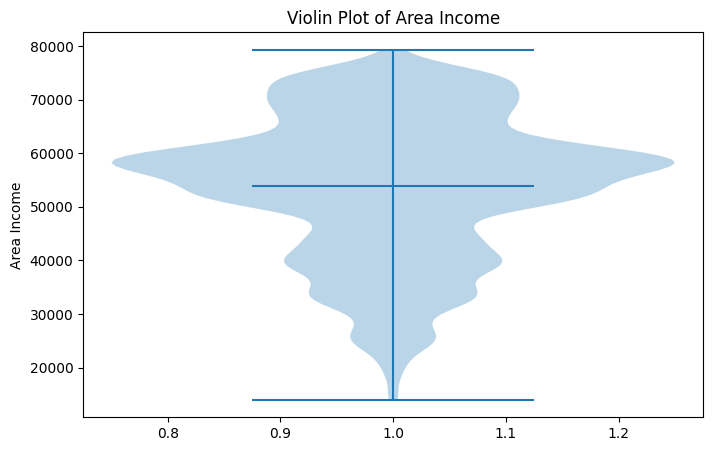

In [43]:
plt.figure(figsize=(8,5))
plt.violinplot(df['Area Income'], showmeans=True)
plt.title('Violin Plot of Area Income')
plt.ylabel('Area Income')
plt.show()


## 10) Customized Violin Plot for Age

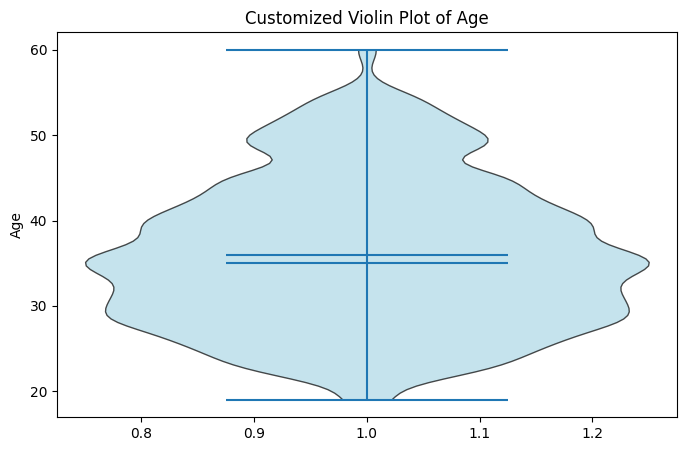

In [44]:
fig, ax = plt.subplots(figsize=(8,5))

parts = ax.violinplot(df['Age'], showmeans=True, showmedians=True, showextrema=True)

for pc in parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

ax.set_title('Customized Violin Plot of Age')
ax.set_ylabel('Age')
plt.show()


## 11) Violin Plot for Daily Time Spent on Site for Top 5 Countries

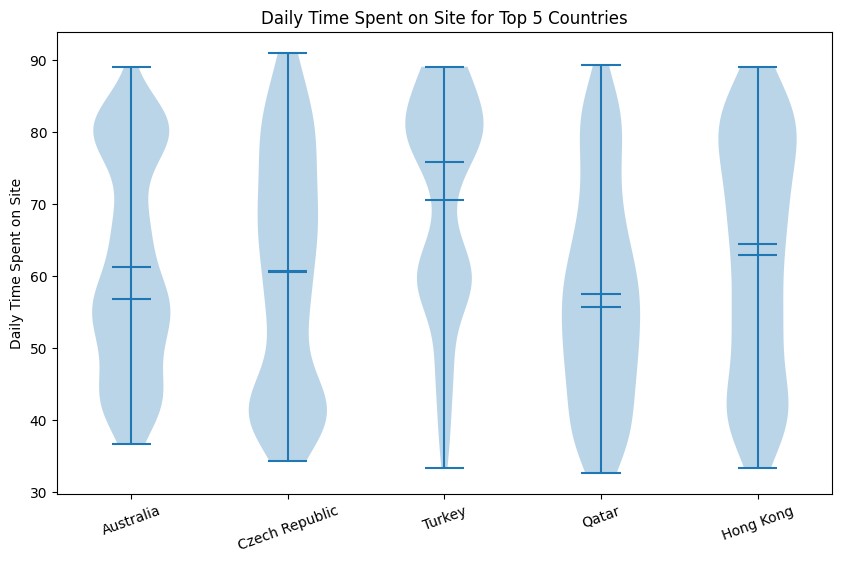

In [45]:
top5_countries = df['Country'].value_counts().head(5).index
data = [df[df['Country'] == c]['Daily Time Spent on Site'] for c in top5_countries]

plt.figure(figsize=(10,6))
plt.violinplot(data, showmeans=True, showmedians=True)
plt.xticks(range(1, len(top5_countries) + 1), top5_countries, rotation=20)
plt.title('Daily Time Spent on Site for Top 5 Countries')
plt.ylabel('Daily Time Spent on Site')
plt.show()


## 12) Violin Plot + Box Plot for Daily Internet Usage by Clicked on Ad

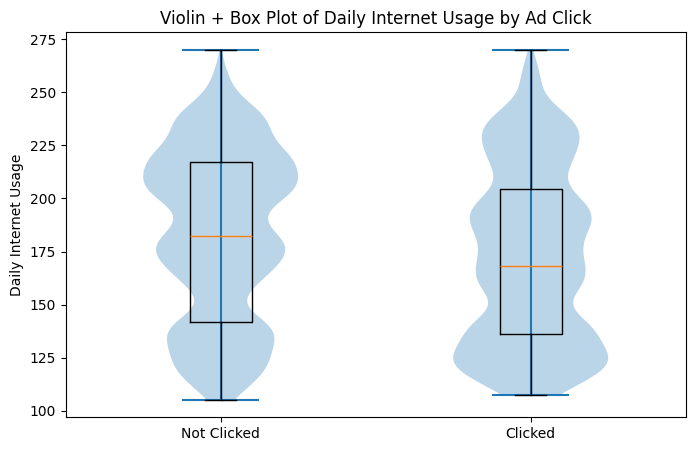

In [46]:
clicked_0 = df[df['Clicked on Ad'] == 0]['Daily Internet Usage']
clicked_1 = df[df['Clicked on Ad'] == 1]['Daily Internet Usage']

fig, ax = plt.subplots(figsize=(8,5))

# Violin plot
ax.violinplot([clicked_0, clicked_1], positions=[1,2], showmeans=False, showmedians=False)

# Overlay box plot
ax.boxplot([clicked_0, clicked_1], positions=[1,2], widths=0.2)

ax.set_xticks([1,2])
ax.set_xticklabels(['Not Clicked', 'Clicked'])
ax.set_title('Violin + Box Plot of Daily Internet Usage by Ad Click')
ax.set_ylabel('Daily Internet Usage')
plt.show()


###
A violin plot shows the full distribution of the data by displaying the density of observations across values. This allows us to see where the data is more concentrated. However, violin plots alone do not clearly show summary statistics such as the median and quartiles.

To address this, a box plot is overlaid on top of the violin plot. The box plot highlights the median, interquartile range (IQR), and potential outliers, while the violin plot shows the overall distribution shape. Combining both visualizations provides a more complete understanding of how daily internet usage differs between users who clicked on the ad and those who did not.

## 13) Divide Dataset into Clicked / Not Clicked Subgroups

In [47]:
clicked_df = df[df['Clicked on Ad'] == 1]
not_clicked_df = df[df['Clicked on Ad'] == 0]

print("Clicked shape:", clicked_df.shape)
print("Not clicked shape:", not_clicked_df.shape)


Clicked shape: (4917, 11)
Not clicked shape: (5083, 11)


## 14) Box Plot for Daily Time Spent on Site + Insight

<Figure size 800x500 with 0 Axes>

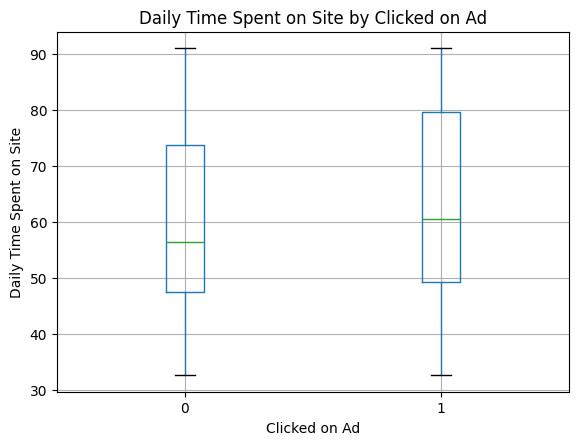

In [56]:
plt.figure(figsize=(8,5))
df.boxplot(column='Daily Time Spent on Site', by='Clicked on Ad')
plt.title('Daily Time Spent on Site by Clicked on Ad')
plt.suptitle('')
plt.xlabel('Clicked on Ad')
plt.ylabel('Daily Time Spent on Site')
plt.show()



###
The box plot allows comparison of the distribution of time spent on the website between users who clicked on the ad and those who did not. Differences in median values, spread, and presence of outliers can indicate whether engagement time is related to ad-click behavior. If users who clicked the ad tend to spend more time on the site, it suggests that user engagement may influence the likelihood of clicking an advertisement.

## 15) Box Plot for Age + Interpretation

<Figure size 800x500 with 0 Axes>

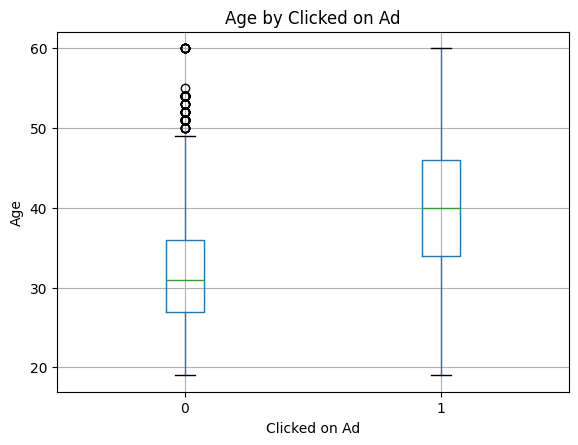

In [55]:
plt.figure(figsize=(8,5))
df.boxplot(column='Age', by='Clicked on Ad')
plt.title('Age by Clicked on Ad')
plt.suptitle('')
plt.xlabel('Clicked on Ad')
plt.ylabel('Age')
plt.show()




###
The box plot of age grouped by ad-click behavior shows how the age distribution differs between users who clicked and those who did not. If the medians differ noticeably, this suggests that age may influence ad interaction. A wider interquartile range indicates greater variability within that group. This analysis helps determine whether age is a meaningful feature for predicting ad clicks.

## 16) Box Plot for Area Income + Interpretation

<Figure size 800x500 with 0 Axes>

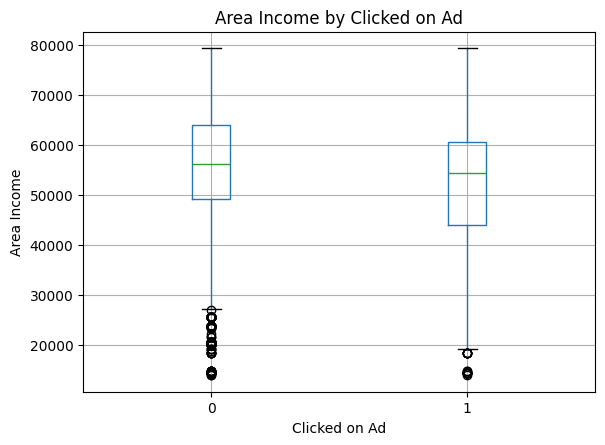

In [57]:
plt.figure(figsize=(8,5))
df.boxplot(column='Area Income', by='Clicked on Ad')
plt.title('Area Income by Clicked on Ad')
plt.suptitle('')
plt.xlabel('Clicked on Ad')
plt.ylabel('Area Income')
plt.show()



###
Differences in median income or spread may suggest that users from different income levels respond differently to ads



## 17) Box Plot for Daily Internet Usage + Insight

<Figure size 800x500 with 0 Axes>

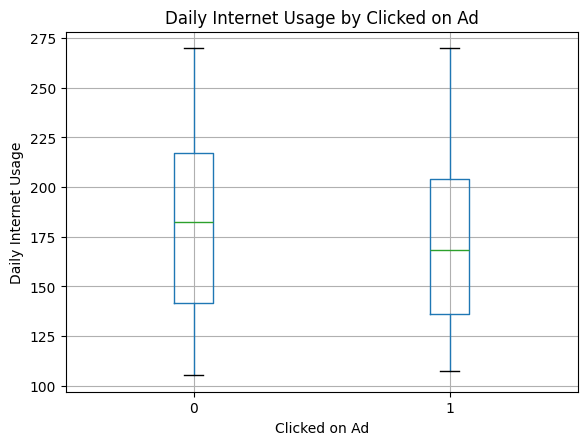

In [58]:
plt.figure(figsize=(8,5))
df.boxplot(column='Daily Internet Usage', by='Clicked on Ad')
plt.title('Daily Internet Usage by Clicked on Ad')
plt.suptitle('')
plt.xlabel('Clicked on Ad')
plt.ylabel('Daily Internet Usage')
plt.show()


###
The box plot shows how internet usage differs between users who clicked the ad and those who did not. If users who clicked the ad have higher median internet usage, it suggests that more active internet users may be more responsive to advertisements. The spread of the distribution also helps identify whether usage behavior varies widely among users.

## 18) Box Plot for Gender Among Users Who Clicked on Ad

<Figure size 800x500 with 0 Axes>

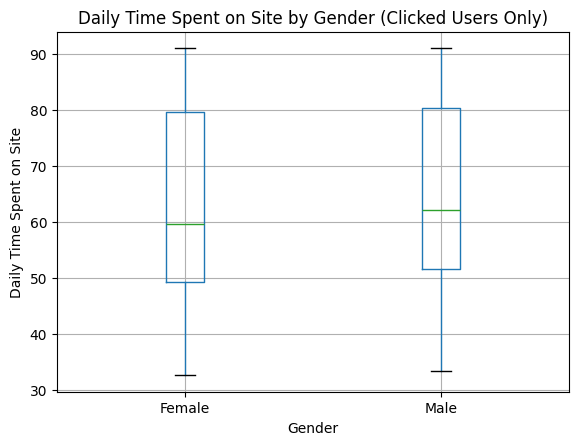

In [59]:
clicked_users = df[df['Clicked on Ad'] == 1]

plt.figure(figsize=(8,5))
clicked_users.boxplot(column='Daily Time Spent on Site', by='Gender')
plt.title('Daily Time Spent on Site by Gender (Clicked Users Only)')
plt.suptitle('')
plt.xlabel('Gender')
plt.ylabel('Daily Time Spent on Site')
plt.show()


###
This visualization focuses only on users who clicked on ads and compares their site engagement by gender. Differences in median time spent on site or variation in the distributions may indicate behavioral differences between male and female users after clicking advertisements. Such insights can be useful for targeted marketing strategies.

## 19) Timestamp Feature Engineering + Box Plot

<Figure size 800x500 with 0 Axes>

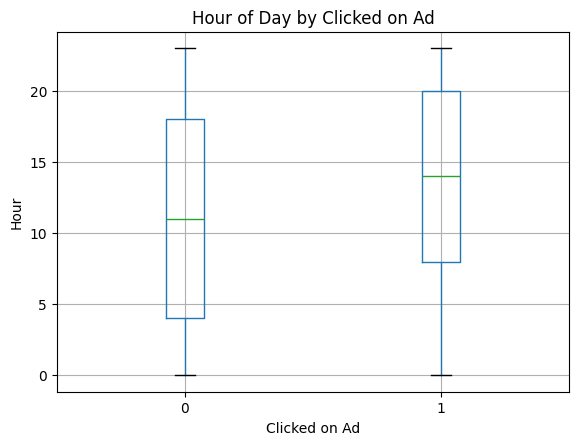

In [60]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour

plt.figure(figsize=(8,5))
df.boxplot(column='Hour', by='Clicked on Ad')
plt.title('Hour of Day by Clicked on Ad')
plt.suptitle('')
plt.xlabel('Clicked on Ad')
plt.ylabel('Hour')
plt.show()


###
The timestamp column contains detailed date and time information that can be transformed into useful features such as hour, day, or month. In this case, extracting the hour using dt.hour allows analysis of user behavior throughout the day. This helps determine whether ad-click activity is more common at certain times, which can be valuable for optimizing ad placement and scheduling.

## 20) Top 5 Countries: Daily Internet Usage by Click Outcome

C:\Users\prani\AppData\Local\Temp\ipykernel_29168\81342663.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=labels)


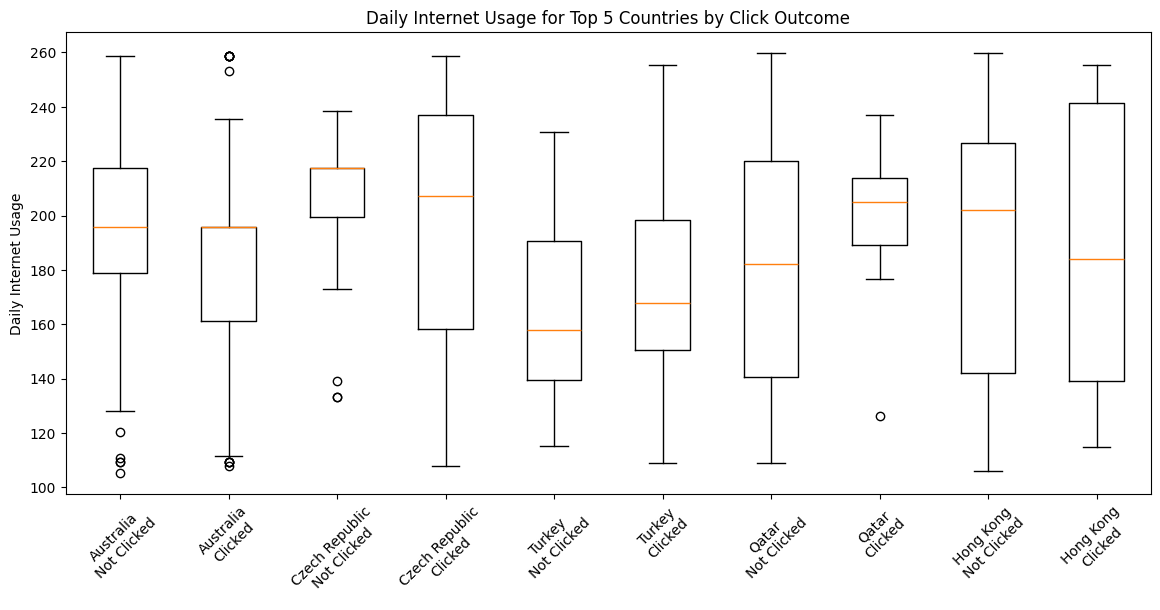

In [61]:
top5_countries = df['Country'].value_counts().head(5).index
filtered = df[df['Country'].isin(top5_countries)]

plot_data = []
labels = []

for country in top5_countries:
    plot_data.append(filtered[(filtered['Country'] == country) & (filtered['Clicked on Ad'] == 0)]['Daily Internet Usage'])
    labels.append(f'{country}\nNot Clicked')

    plot_data.append(filtered[(filtered['Country'] == country) & (filtered['Clicked on Ad'] == 1)]['Daily Internet Usage'])
    labels.append(f'{country}\nClicked')

plt.figure(figsize=(14,6))
plt.boxplot(plot_data, labels=labels)
plt.title('Daily Internet Usage for Top 5 Countries by Click Outcome')
plt.ylabel('Daily Internet Usage')
plt.xticks(rotation=45)
plt.show()


###
Comparing daily internet usage across the top countries and click outcomes allows us to analyze how geographic location influences online behavior and ad engagement. Differences in distributions across countries may indicate cultural or technological factors that affect how users interact with advertisements. This helps identify potential regional differences in advertising effectiveness.

## Final Conclusion

This notebook performs:
- data loading and initial exploration,
- duplicate and null-value checks,
- basic cleaning for `Age` and `Area Income`,
- box plots and violin plots for several CTR-related variables,
- subgroup comparisons by click behavior, gender, age group, country, and hour of day.

These visualizations help identify which user features may be associated with ad-click behavior.
